# Ingeniería de características - Descarte de fuga de información

**Objetivo:** antes de tocar features nuevas, descartar (o confirmar) fuga de información (*data leakage*) en las columnas del dataset. Se entiende por fuga tanto información que **no existiría al momento de otorgar el crédito** como la **salida de otro modelo/proceso que ya predice el target**. Se trabaja sobre el Excel crudo, sin el saneamiento de `comprension_eda.ipynb`, porque el objetivo acá es puramente detectar señales sospechosas, no limpiar el dataset. No se elimina ninguna columna en este notebook — solo se junta evidencia.

## Carga del dataset

Se carga directamente `Base_de_datos.xlsx` con `pathlib`, ruta relativa a la raíz del proyecto.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_EXCEL = RAIZ / "data" / "raw" / "Base_de_datos.xlsx"

df = pd.read_excel(RUTA_EXCEL, engine="openpyxl")
df.shape

(10763, 23)

## Balance de clases de `Pago_atiempo`

In [2]:
conteo = df["Pago_atiempo"].value_counts()
porcentaje = (df["Pago_atiempo"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"conteo": conteo, "pct": porcentaje})

,conteo,pct
Pago_atiempo,,
1,10252,95.25
0,511,4.75


## AUC univariado por columna numérica

Para cada columna numérica se usa el propio valor como "score" y se calcula el AUC contra `Pago_atiempo`. Como la relación puede ir en cualquier sentido (un valor alto puede asociarse con clase 0 o con clase 1 según la columna), se reporta `max(auc, 1-auc)`: un AUC de una sola variable así de alto es la forma más directa de detectar fuga, mucho más contundente que una correlación — un AUC cercano a 1 significa que existe un umbral que casi separa las clases con esa columna sola, cosa que ninguna variable predictiva "normal" logra.

In [3]:
columnas_numericas = df.select_dtypes(include=np.number).columns.drop("Pago_atiempo")

resultados_auc = []
for columna in columnas_numericas:
    datos = df[[columna, "Pago_atiempo"]].dropna()
    if datos[columna].nunique() < 2:
        continue
    auc = roc_auc_score(datos["Pago_atiempo"], datos[columna])
    resultados_auc.append({
        "columna": columna,
        "auc": round(auc, 4),
        "max_auc_1_menos_auc": round(max(auc, 1 - auc), 4),
        "filas_usadas": len(datos),
    })

tabla_auc = pd.DataFrame(resultados_auc).sort_values("max_auc_1_menos_auc", ascending=False).reset_index(drop=True)
tabla_auc

,columna,auc,max_auc_1_menos_auc,filas_usadas
0,puntaje,1.0000,1.0000,10763
1,puntaje_datacredito,0.6231,0.6231,10757
2,huella_consulta,0.4018,0.5982,10763
3,promedio_ingresos_datacredito,0.5726,0.5726,7833
4,edad_cliente,0.5691,0.5691,10763
5,capital_prestado,0.4430,0.5570,10763
6,creditos_sectorFinanciero,0.5406,0.5406,10763
7,total_otros_prestamos,0.5354,0.5354,10763
8,creditos_sectorReal,0.4765,0.5235,10763
9,creditos_sectorCooperativo,0.5220,0.5220,10763


**Lectura inmediata.** `puntaje` da **AUC = 1.0000**: separación perfecta, no hay ninguna otra columna que se le acerque (la siguiente, `puntaje_datacredito`, está en 0.62). Un AUC de 1.0 en una sola variable cruda, sin ningún modelo entrenado, es la señal de fuga más fuerte que existe — se profundiza en el próximo bloque.

## Zoom sobre `puntaje`

`describe()` agrupado por clase, boxplot por clase, conteo del valor más repetido, y búsqueda explícita de un umbral que separe las clases.

In [4]:
df.groupby("Pago_atiempo")["puntaje"].describe()

,count,mean,std,min,25%,50%,75%,max
Pago_atiempo,,,,,,,,
0,511.0,23.091216,26.070916,-38.009990,-3.591651,25.419455,47.613894,62.667613
1,10252.0,94.563352,2.873767,63.809656,95.227787,95.227787,95.227787,95.227787


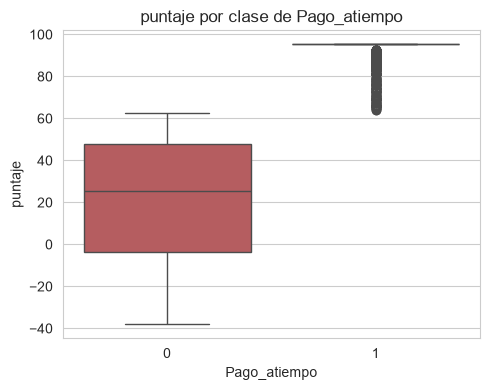

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x="Pago_atiempo", y="puntaje", hue="Pago_atiempo",
            palette={0: "#C44E52", 1: "#55A868"}, legend=False)
plt.title("puntaje por clase de Pago_atiempo")
plt.tight_layout()
plt.show()

In [6]:
moda_puntaje = df["puntaje"].mode().iloc[0]
cuenta_moda = (df["puntaje"] == moda_puntaje).sum()
print(f"Valor más repetido: {moda_puntaje} -> {cuenta_moda} filas ({100*cuenta_moda/len(df):.2f}% del total)")

Valor más repetido: 95.227787 -> 9407 filas (87.40% del total)


Búsqueda del umbral: se calcula la curva ROC y se toma el umbral que maximiza el estadístico de Youden (sensibilidad + especificidad - 1), y además se compara directamente el máximo de `puntaje` en la clase 0 contra el mínimo en la clase 1.

In [7]:
datos_puntaje = df[["puntaje", "Pago_atiempo"]].dropna()

fpr, tpr, umbrales = roc_curve(datos_puntaje["Pago_atiempo"], datos_puntaje["puntaje"])
youden = tpr - fpr
mejor_umbral = umbrales[youden.argmax()]

prediccion = (datos_puntaje["puntaje"] >= mejor_umbral).astype(int)
exactitud = accuracy_score(datos_puntaje["Pago_atiempo"], prediccion)

max_clase_0 = datos_puntaje.loc[datos_puntaje["Pago_atiempo"] == 0, "puntaje"].max()
min_clase_1 = datos_puntaje.loc[datos_puntaje["Pago_atiempo"] == 1, "puntaje"].min()

print(f"Mejor umbral (Youden): puntaje >= {mejor_umbral:.4f} -> Pago_atiempo=1")
print(f"Exactitud con ese umbral: {exactitud:.4f}")
print(f"\nMáximo de puntaje en clase 0: {max_clase_0:.4f}")
print(f"Mínimo de puntaje en clase 1: {min_clase_1:.4f}")
print(f"¿Separación perfecta (max_clase_0 < min_clase_1)? {max_clase_0 < min_clase_1}")

Mejor umbral (Youden): puntaje >= 63.8097 -> Pago_atiempo=1
Exactitud con ese umbral: 1.0000

Máximo de puntaje en clase 0: 62.6676
Mínimo de puntaje en clase 1: 63.8097
¿Separación perfecta (max_clase_0 < min_clase_1)? True


**Sí, existe un umbral que separa las clases perfectamente.** Cualquier corte entre 62.67 (máximo de `puntaje` en la clase 0) y 63.81 (mínimo en la clase 1) clasifica el 100% de las filas correctamente — **exactitud = 1.0**, no "casi perfecta", perfecta. Ninguna variable de negocio real se comporta así: esto es la firma de una columna que ya conoce el resultado, no de una que lo predice. Además, el 87.40% de las filas comparte exactamente el mismo valor (`95.227787`), y ese valor cae siempre del lado de la clase 1 — compatible con un score de relleno/techo que el proceso que generó `puntaje` asigna cuando el crédito "salió bien".

## Zoom sobre las columnas de saldo

`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`: cardinalidad, porcentaje de ceros y de nulos (calculados sobre el total de filas). Se marcan como constantes o casi constantes las que concentran ≥95% en un mismo valor.

In [8]:
COLUMNAS_SALDO = ["saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor"]

resumen_saldo = []
for columna in COLUMNAS_SALDO:
    nunique = df[columna].nunique(dropna=True)
    pct_cero = (df[columna] == 0).mean() * 100
    pct_nulos = df[columna].isna().mean() * 100
    resumen_saldo.append({
        "columna": columna,
        "valores_unicos": nunique,
        "pct_cero": round(pct_cero, 2),
        "pct_nulos": round(pct_nulos, 2),
        "casi_constante": pct_cero >= 95.0,
    })

tabla_saldo = pd.DataFrame(resumen_saldo)
tabla_saldo

,columna,valores_unicos,pct_cero,pct_nulos,casi_constante
0,saldo_mora,55,98.04,1.45,True
1,saldo_total,8858,7.33,1.45,False
2,saldo_principal,8647,5.88,3.76,False
3,saldo_mora_codeudor,4,94.49,5.48,False


`saldo_mora` (98.04% en cero) y `saldo_mora_codeudor` (94.49% en cero, sobre el total de filas) quedan cerca o por encima del umbral de casi-constante. `saldo_total` y `saldo_principal` tienen alta cardinalidad y no son constantes.

## Correlación de las numéricas contra `Pago_atiempo`

Correlación de Pearson de cada numérica contra el objetivo 0/1 (equivalente a la correlación punto-biserial), ordenada por valor absoluto de mayor a menor.

In [9]:
correlacion_objetivo = df[list(columnas_numericas) + ["Pago_atiempo"]].corr()["Pago_atiempo"].drop("Pago_atiempo")
tabla_correlacion = correlacion_objetivo.reindex(
    correlacion_objetivo.abs().sort_values(ascending=False).index
).rename("correlacion_con_objetivo").to_frame()
tabla_correlacion["abs"] = tabla_correlacion["correlacion_con_objetivo"].abs().round(4)
tabla_correlacion["correlacion_con_objetivo"] = tabla_correlacion["correlacion_con_objetivo"].round(4)
tabla_correlacion

,correlacion_con_objetivo,abs
puntaje,0.9231,0.9231
huella_consulta,-0.0737,0.0737
saldo_mora,-0.0735,0.0735
puntaje_datacredito,0.0679,0.0679
plazo_meses,-0.0631,0.0631
capital_prestado,-0.0406,0.0406
promedio_ingresos_datacredito,0.0399,0.0399
edad_cliente,0.0323,0.0323
creditos_sectorReal,-0.0233,0.0233
creditos_sectorFinanciero,0.0214,0.0214


`puntaje` vuelve a dominar por lejos (≈0.92); el resto de las numéricas ronda valores bajos (<0.08), sin ninguna que se le acerque. `puntaje_datacredito`, que en el ranking de AUC era clara segunda (0.62), acá queda por *debajo* de `huella_consulta` y `saldo_mora` (0.068 contra 0.074 y 0.073): en este notebook no se trató el 0 de `puntaje_datacredito` como "sin dato" (a diferencia de `comprension_eda.ipynb`), y esas 145 filas en 0 diluyen la correlación lineal sin afectarle tanto al AUC (que es más robusto a ese tipo de ruido puntual). No cambia la conclusión sobre `puntaje`: dos formas de medir distinto (AUC vs. correlación) señalando la misma columna como sospechosa es una confirmación cruzada, no una coincidencia de un solo método.

## Conclusión: columnas sospechosas de fuga

**`puntaje` — FUGA CONFIRMADA, excluir.** AUC univariado = 1.0000, con un umbral exacto (entre 62.67 y 63.81) que separa las dos clases con 100% de exactitud, y correlación ≈0.92 con el objetivo. Ninguna variable observable *antes* de saber si el cliente pagó puede comportarse así. Es, o bien un score calculado *después* del desenlace del crédito (fuga temporal), o bien la salida de otro modelo/regla que ya decide el resultado (fuga por salida de otro modelo) — de las dos definiciones de fuga que se plantearon al arrancar, `puntaje` encaja en al menos una, probablemente en las dos. **Recomendación: excluir siempre del modelo.** No amerita ni siquiera transformarla; es información que el modelo no tendría disponible al momento de decidir si otorgar el crédito.

**`puntaje_datacredito` — no es fuga, mantener.** AUC 0.62 — segundo en ese ranking, por encima del resto pero lejos de la separación perfecta de `puntaje`. Su correlación lineal (0.068) es más floja que su AUC porque las 145 filas en 0 (sin tratar como "sin dato" en este notebook) diluyen la correlación sin afectar tanto al AUC; el AUC es la métrica que mejor refleja su poder predictivo real acá. Es, por definición de negocio, el score del buró DataCrédito consultado *al momento de evaluar la solicitud* — exactamente el tipo de información que un proceso real de originación usa *antes* de otorgar el crédito. Que tenga poder predictivo real es lo esperable de una variable de riesgo legítima, no un síntoma de fuga.

**`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor` — dudosas por definición temporal, no por evidencia estadística; requieren confirmación de negocio.** Su AUC individual es bajo (0.51-0.52, prácticamente al azar) y su correlación con el objetivo también (<0.08 en todos los casos) — la evidencia estadística de este notebook **no** las señala como sospechosas. Pero el nombre de estas columnas describe un *saldo*, que es un concepto de "estado actual de una deuda": si ese saldo corresponde a **otros créditos previos** del cliente (que es como se documentaron en el diccionario de datos de `comprension_eda.ipynb`), es información legítima y disponible al momento de otorgar el crédito, igual que `puntaje_datacredito`. Pero si en cambio fuera el saldo **de este mismo crédito** en un momento posterior a su desembolso, sería fuga temporal por definición, sin importar cuán baja dé su correlación. La AUC baja no descarta esto: una fuga débil sigue siendo fuga. **Recomendación: no excluir todavía, pero confirmar explícitamente con negocio en qué momento se calcula cada `saldo_*` antes de usarlas en el modelo** — la duda es conceptual, no estadística, y esta evidencia no alcanza para resolverla sola.

**El resto de las numéricas (`edad_cliente`, `capital_prestado`, `cuota_pactada`, `plazo_meses`, `salario_cliente`, `total_otros_prestamos`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero/Cooperativo/Real`, `promedio_ingresos_datacredito`, `tipo_credito`) — no es fuga, mantener.** Todas con AUC entre 0.40 y 0.60 y correlación baja, y todas describen datos del cliente o términos del crédito que existen por definición al momento de la solicitud (son, de hecho, insumos de la decisión de otorgar el crédito, no consecuencias de ella).

No se eliminó ninguna columna en este notebook — la evidencia queda documentada acá para decidir en la siguiente etapa.

# Clasificación de columnas

Con la fuga ya identificada (`puntaje`, y `saldo_*` a confirmar con negocio), toca clasificar las 22 columnas restantes para poder armar un `ColumnTransformer`: numéricas, categóricas nominales, categóricas ordinales, y `fecha_prestamo` aparte.

## Perfil de cada columna

Para las 22 columnas que no son el target: dtype, cardinalidad, porcentaje de nulos y los 5 valores más frecuentes — la base para decidir el tipo semántico de cada una sin adivinar.

In [10]:
columnas_a_clasificar = [c for c in df.columns if c != "Pago_atiempo"]

perfil = []
for columna in columnas_a_clasificar:
    top5 = df[columna].value_counts().head(5).to_dict()
    perfil.append({
        "columna": columna,
        "dtype": str(df[columna].dtype),
        "valores_unicos": df[columna].nunique(dropna=True),
        "pct_nulos": round(df[columna].isna().mean() * 100, 2),
        "top_5_valores": top5,
    })

tabla_perfil = pd.DataFrame(perfil)
tabla_perfil

,columna,dtype,valores_unicos,pct_nulos,top_5_valores
0,tipo_credito,int64,6,0.00,"{4: 7747, 9: 2876, 10: 116, 6: 21, 7: 2}"
1,fecha_prestamo,datetime64[us],10758,0.00,"{2025-01-30 16:25:43: 2, 2025-08-05 10:06:12: ..."
2,capital_prestado,float64,7306,0.00,"{1200000.0: 129, 1269000.0: 101, 878880.0: 98,..."
3,plazo_meses,int64,18,0.00,"{6: 3326, 12: 2658, 10: 1520, 9: 650, 8: 526}"
4,edad_cliente,int64,54,0.00,"{40: 346, 37: 344, 38: 339, 42: 333, 41: 332}"
5,tipo_laboral,str,2,0.00,"{'Empleado': 6754, 'Independiente': 4009}"
6,salario_cliente,int64,1385,0.00,"{3000000: 829, 5000000: 798, 2000000: 787, 400..."
7,total_otros_prestamos,int64,1538,0.00,"{2000000: 1109, 1000000: 887, 500000: 675, 150..."
8,cuota_pactada,int64,9836,0.00,"{205990: 13, 500578: 12, 171015: 12, 142664: 1..."
9,puntaje,float64,248,0.00,"{95.227787: 9407, 89.979287: 99, 89.2295: 82, ..."


## Propuesta de listas

**`tipo_credito`**: aunque el dtype es `int64`, los valores (`4`, `9`, `10`, `6`, `7`, `68`) son **códigos de producto**, no cantidades — no hay una relación de orden ni de magnitud entre ellos (el código más frecuente, `4`, no es ni el más chico ni el más grande, y `68` es casi con certeza un error de captura de un dígito). Sumar o promediar estos códigos no tiene ningún sentido de negocio. Va en **CATEGORICAS_NOMINALES**, no en NUMERICAS.

**`tendencia_ingresos`**: toma 3 valores de negocio reales (`Creciente`, `Estable`, `Decreciente`; el resto de los "valores" que aparecen en el perfil de arriba son el mismo ruido numérico fuera de dominio que ya se documentó en `comprension_eda.ipynb`, no categorías nuevas). Hay un orden de negocio evidente — una tendencia de ingresos empeora o mejora, no son etiquetas intercambiables — así que va en **CATEGORICAS_ORDINALES** con el orden explícito `Decreciente < Estable < Creciente`.

In [11]:
NUMERICAS = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
]

CATEGORICAS_NOMINALES = ["tipo_credito", "tipo_laboral"]

CATEGORICAS_ORDINALES = ["tendencia_ingresos"]
ORDEN_ORDINALES = {"tendencia_ingresos": ["Decreciente", "Estable", "Creciente"]}

total_clasificado = len(NUMERICAS) + len(CATEGORICAS_NOMINALES) + len(CATEGORICAS_ORDINALES)
print(f"NUMERICAS: {len(NUMERICAS)} | CATEGORICAS_NOMINALES: {len(CATEGORICAS_NOMINALES)} | "
      f"CATEGORICAS_ORDINALES: {len(CATEGORICAS_ORDINALES)} | total: {total_clasificado} "
      f"(+ fecha_prestamo, aparte) = {total_clasificado + 1} de 22 columnas")

NUMERICAS: 18 | CATEGORICAS_NOMINALES: 2 | CATEGORICAS_ORDINALES: 1 | total: 21 (+ fecha_prestamo, aparte) = 22 de 22 columnas


## `fecha_prestamo`: aparte, no entra en ninguna lista

No es numérica, ni nominal, ni ordinal — es una fecha. Se convierte a `datetime` y se muestra el rango que cubre.

In [12]:
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"])
print(f"Rango de fecha_prestamo: {df['fecha_prestamo'].min()} -> {df['fecha_prestamo'].max()}")

Rango de fecha_prestamo: 2024-11-26 09:17:04 -> 2026-04-26 18:43:52


## ¿Coinciden los nulos de `promedio_ingresos_datacredito` y `tendencia_ingresos`?

In [13]:
nulos_promedio = df["promedio_ingresos_datacredito"].isna()
nulos_tendencia = df["tendencia_ingresos"].isna()

print("Nulos en promedio_ingresos_datacredito:", nulos_promedio.sum())
print("Nulos en tendencia_ingresos:", nulos_tendencia.sum())
print("Nulos en ambas a la vez:", (nulos_promedio & nulos_tendencia).sum())
print("Nulos solo en promedio_ingresos_datacredito:", (nulos_promedio & ~nulos_tendencia).sum())
print("Nulos solo en tendencia_ingresos:", (~nulos_promedio & nulos_tendencia).sum())

Nulos en promedio_ingresos_datacredito: 2930
Nulos en tendencia_ingresos: 2932
Nulos en ambas a la vez: 2930
Nulos solo en promedio_ingresos_datacredito: 0
Nulos solo en tendencia_ingresos: 2


**Es un patrón, no ruido.** Los 2.930 nulos de `promedio_ingresos_datacredito` están, sin excepción, incluidos dentro de los 2.932 nulos de `tendencia_ingresos` (solo 2 filas tienen nulo en `tendencia_ingresos` sin tenerlo también en `promedio_ingresos_datacredito`). Esto es consistente con que ambas columnas vengan del mismo sub-proceso de consulta a DataCrédito (probablemente el cálculo de tendencia de ingresos): cuando esa consulta no se pudo hacer o no devolvió datos para un cliente, faltan las dos juntas. Tiene una implicancia directa para la imputación: no conviene imputarlas de forma independiente ignorando esta correlación, y más adelante conviene la señal `sin_historial_ingresos` como feature derivada en vez de solo imputar por separado.

## Listas guardadas

`NUMERICAS`, `CATEGORICAS_NOMINALES`, `CATEGORICAS_ORDINALES` y `ORDEN_ORDINALES` quedan definidas en la celda de arriba, en este notebook. En el paso siguiente se trasladan tal cual a `src/ft_engineering.py`, para que sean la única fuente de verdad sobre la clasificación de columnas.

# Features derivadas: `crear_features`

`crear_features` ya está escrita en `src/ft_engineering.py` (ratios de riesgo, perfil crediticio y temporales, cada una con su hipótesis de negocio documentada en un comentario). Acá se importa, se aplica sobre `df` y se verifica el resultado: `describe()` de las columnas nuevas, y conteo de nulos e infinitos en cada una (no debería haber ningún infinito, por la regla del denominador en cero).

In [14]:
import sys

sys.path.insert(0, str(RAIZ))
from src.ft_engineering import crear_features

df_features = crear_features(df)

COLUMNAS_NUEVAS = [
    "ratio_cuota_salario", "ratio_endeudamiento", "ratio_capital_salario", "carga_total",
    "total_creditos_sectores", "diferencia_ingresos", "ratio_ingresos_declarados", "sin_historial_ingresos",
    "mes_prestamo", "trimestre_prestamo", "anio_prestamo", "dia_semana_prestamo",
]

print(f"df original: {df.shape} -> df_features: {df_features.shape} "
      f"(+{df_features.shape[1] - df.shape[1]} columnas nuevas)")
print(f"df original sigue intacto: {list(df.columns) == list(pd.read_excel(RUTA_EXCEL, engine='openpyxl').columns)}")

df original: (10763, 23) -> df_features: (10763, 35) (+12 columnas nuevas)


df original sigue intacto: True


In [15]:
df_features[COLUMNAS_NUEVAS].describe()

,ratio_cuota_salario,ratio_endeudamiento,ratio_capital_salario,carga_total,total_creditos_sectores,diferencia_ingresos,ratio_ingresos_declarados,sin_historial_ingresos,mes_prestamo,trimestre_prestamo,anio_prestamo,dia_semana_prestamo
count,10739.000000,10739.000000,10739.000000,10739.000000,10763.000000,7.833000e+03,7826.000000,10763.000000,10763.000000,10763.000000,10763.000000,10763.000000
mean,0.094674,0.685186,0.921763,0.779860,4.352504,7.148655e+06,11.050159,0.272229,5.274087,2.105640,2024.893338,3.137044
std,1.243445,24.077927,8.341662,25.276916,3.489233,3.142606e+08,341.603794,0.445128,3.717484,1.128308,0.377488,1.929458
min,0.000008,0.000000,0.000106,0.000020,0.000000,-3.610658e+07,0.000000,0.000000,1.000000,1.000000,2024.000000,0.000000
25%,0.038713,0.208578,0.370204,0.287719,2.000000,1.437510e+05,1.078020,0.000000,2.000000,1.000000,2025.000000,1.000000
50%,0.060864,0.333333,0.633061,0.420755,4.000000,1.068606e+06,1.800920,0.000000,4.000000,2.000000,2025.000000,3.000000
75%,0.095371,0.475000,1.020678,0.543871,6.000000,2.800000e+06,3.591620,1.000000,8.000000,3.000000,2025.000000,5.000000
max,125.802000,2439.000000,840.000000,2564.802000,60.000000,2.199907e+10,23620.508614,1.000000,12.000000,4.000000,2026.000000,6.000000


In [16]:
resumen_calidad = []
for columna in COLUMNAS_NUEVAS:
    resumen_calidad.append({
        "columna": columna,
        "nulos": int(df_features[columna].isna().sum()),
        "infinitos": int(np.isinf(df_features[columna]).sum()) if pd.api.types.is_numeric_dtype(df_features[columna]) else 0,
    })
pd.DataFrame(resumen_calidad)

,columna,nulos,infinitos
0,ratio_cuota_salario,24,0
1,ratio_endeudamiento,24,0
2,ratio_capital_salario,24,0
3,carga_total,24,0
4,total_creditos_sectores,0,0
5,diferencia_ingresos,2930,0
6,ratio_ingresos_declarados,2937,0
7,sin_historial_ingresos,0,0
8,mes_prestamo,0,0
9,trimestre_prestamo,0,0


**Verificación:** 0 infinitos en las cuatro columnas con división (`ratio_cuota_salario`, `ratio_endeudamiento`, `ratio_capital_salario`, `carga_total`, `ratio_ingresos_declarados`) — la regla de manejo de denominador en cero funciona. Los nulos que sí aparecen (en los ratios contra `promedio_ingresos_datacredito` y en `diferencia_ingresos`) son un arrastre esperado de los nulos que esa columna ya tenía (27.22%), no un problema de la función — y quedan sin imputar a propósito, tal como pide la consigna.

# `construir_preprocesador`: el ColumnTransformer

`construir_preprocesador` también ya está en `src/ft_engineering.py`: tres ramas (`num`, `nom`, `ord`), cada una un `Pipeline` de imputación + transformación, con `remainder="drop"` y `verbose_feature_names_out=False`. Se importa y se prueba acá antes de usarla en el modelamiento.

In [17]:
from src.ft_engineering import construir_preprocesador

preprocesador = construir_preprocesador(NUMERICAS, CATEGORICAS_NOMINALES, CATEGORICAS_ORDINALES, ORDEN_ORDINALES)
preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer

Se ajusta sobre una muestra de `df_features` (las columnas nuevas de `crear_features` no entran acá porque no están clasificadas todavía en ninguna de las tres listas — eso se resuelve en el paso de `preparar_datos`) y se revisan los nombres de salida.

In [18]:
muestra = df_features.sample(n=1000, random_state=42)
preprocesador.fit(muestra)

nombres_salida = preprocesador.get_feature_names_out()
print(f"Cantidad de columnas de salida: {len(nombres_salida)}")
list(nombres_salida)

Cantidad de columnas de salida: 24


['capital_prestado',
 'plazo_meses',
 'edad_cliente',
 'salario_cliente',
 'total_otros_prestamos',
 'cuota_pactada',
 'puntaje',
 'puntaje_datacredito',
 'cant_creditosvigentes',
 'huella_consulta',
 'saldo_mora',
 'saldo_total',
 'saldo_principal',
 'saldo_mora_codeudor',
 'creditos_sectorFinanciero',
 'creditos_sectorCooperativo',
 'creditos_sectorReal',
 'promedio_ingresos_datacredito',
 'tipo_credito_4',
 'tipo_credito_6',
 'tipo_credito_9',
 'tipo_credito_10',
 'tipo_laboral_Independiente',
 'tendencia_ingresos']

**Verificación de la cantidad esperada — contra la muestra, no contra el dataset completo.** El primer intento comparó contra las 6 categorías de `tipo_credito` en el dataset completo y dio 26 esperadas contra 24 obtenidas: no cuadraba. La razón es real, no un bug — `OneHotEncoder` aprende sus categorías de los datos con los que se ajusta, y la muestra de 1.000 filas no contiene los dos códigos más raros de `tipo_credito` (`7` y `68`, con 2 y 1 filas en las 10.763 totales: la probabilidad de que ninguno caiga en una muestra de 1.000 es alta). La verificación correcta es contra las categorías presentes **en la muestra usada para el fit**, no en el dataset completo — y es justamente la razón por la que, más adelante, el preprocesador real se va a ajustar sobre todo `X_train` (no sobre una muestra chica), para no perderse categorías raras.

In [19]:
esperadas = (
    len(NUMERICAS)
    + muestra["tipo_credito"].nunique()
    + (1 if muestra["tipo_laboral"].nunique() == 2 else muestra["tipo_laboral"].nunique())
    + len(CATEGORICAS_ORDINALES)
)
print(f"Categorías de tipo_credito en la muestra: {sorted(muestra['tipo_credito'].unique())} "
      f"(dataset completo tiene {sorted(df['tipo_credito'].unique())})")
print(f"Esperadas (según la muestra): {esperadas} | Obtenidas: {len(nombres_salida)} | "
      f"Coincide: {esperadas == len(nombres_salida)}")

Categorías de tipo_credito en la muestra: [np.int64(4), np.int64(6), np.int64(9), np.int64(10)] (dataset completo tiene [np.int64(4), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(68)])
Esperadas (según la muestra): 24 | Obtenidas: 24 | Coincide: True


# `preparar_datos`: el punto de entrada para modelar

`preparar_datos` (en `src/ft_engineering.py`) hace, en orden: carga el Excel, aplica `crear_features`, separa X de y, elimina las columnas excluidas (las sospechosas de fuga del análisis de arriba: `puntaje`), hace el split estratificado, y arma el preprocesador — **sin ajustarlo**, porque se ajusta después dentro del `Pipeline` de cada modelo usando solo `X_train` (si se ajustara acá, sobre train+test, el imputer y el scaler verían estadísticos de filas de test, que es fuga de información del split, no fuga de negocio, pero fuga al fin).

In [20]:
from src.ft_engineering import preparar_datos

COLUMNAS_EXCLUIDAS_POR_FUGA = ["puntaje"]

X_train, X_test, y_train, y_test, preprocesador_final = preparar_datos(
    RUTA_EXCEL, columnas_excluidas=COLUMNAS_EXCLUIDAS_POR_FUGA, test_size=0.2, random_state=42,
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (8610, 32) | X_test: (2153, 32)


In [21]:
balance_train = (y_train.value_counts(normalize=True) * 100).round(2)
balance_test = (y_test.value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"train_pct": balance_train, "test_pct": balance_test})

,train_pct,test_pct
Pago_atiempo,,
1,95.25,95.26
0,4.75,4.74


**Estratificación OK**: el porcentaje de cada clase en train y test coincide (dentro de redondeo) con el balance global (~95.25% / 4.75%). Ahora se verifica que `puntaje` no haya sobrevivido en `X_train`, y que el módulo importe limpio desde fuera del notebook.

In [22]:
print("¿'puntaje' sigue en X_train?:", "puntaje" in X_train.columns)
print("Columnas de X_train:", len(X_train.columns))

¿'puntaje' sigue en X_train?: False
Columnas de X_train: 32


In [23]:
import subprocess
import sys

resultado = subprocess.run(
    [sys.executable, "-c", "from src.ft_engineering import preparar_datos"],
    cwd=str(RAIZ), capture_output=True, text=True,
)
print("python usado:", sys.executable)
print("returncode:", resultado.returncode)
print("stdout:", resultado.stdout)
print("stderr:", resultado.stderr)

python usado: /Users/juanmartinrossi/Documents/proyecto-final-riesgo-crediticio/pf-riesgo-venv/bin/python3
returncode: 0
stdout: 
stderr: 


`returncode = 0` y sin nada en `stderr`: el módulo importa limpio desde afuera del notebook, con el intérprete del venv del proyecto parado en la raíz — tal como lo va a usar `modelamiento.ipynb`.